# The rebrand pop — do `.com` / `Blockchain` / `AI` name changes pay? 🪧
### The company that renames toward the hot theme, pops, and 'gives it back' — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pop_then_dump%3F: Busted](https://img.shields.io/badge/Pop_then_dump%3F-Busted-8b949e?style=flat-square)

There's a great market story: a sleepy little company **renames itself toward whatever's hot** — slap `.com` on it in 1999, become *Long **Blockchain** Corp* in 2017, add `**AI**` in 2023 — and the stock **pops**. Then, once the hype cools, it **gives it all back**. Long Island Iced Tea → Long Blockchain jumped ~200% in a day; Kodak's 'KodakCoin' tripled. Free money on a press release, then a short on the way down.

It's a fun story. This notebook asks whether it's a *real, repeatable* effect or just the two or three legends we remember — by building a transparent table of **~25 real rebrands** and looking at what actually happened to all of them.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The most spectacular rebrands — Long Blockchain, KodakCoin — **went bust and vanished from the data**. So the names we *can* still price are the ones that *didn't* collapse. That biases everything **against** the 'give it back' story — which makes it all the more telling that the story still doesn't show up. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from name_change_effect import data, strategy as st

HAVE_REAL = data.have_real()
B = data.load_real() if HAVE_REAL else None
EV = st.collect_events(B) if HAVE_REAL else None
print("real rebrand-tape cache present:", HAVE_REAL,
      "| events priced:", (0 if EV is None else len(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 25, 'n_delisted': 8, 'n_priced': 21, 'pop': (1.24, 52, 0.51, 0.496), 'fade': (16.22, 52, 1.16, 0.089), 'waves': [('dot-com', 7, -1.31, -3.09), ('blockchain', 6, 1.93, 61.95), ('AI', 8, 2.96, -1.18)], 'robust': [('3/40', 21, -1.48, -0.46, 16.19, 1.32), ('5/60', 21, 1.24, 0.51, 16.22, 1.16), ('10/120', 21, 1.09, 0.29, 51.68, 1.36)], 'cost': {'gross_combo': -14.98, 'net_combo': -16.18, 'gross_pop': 1.24, 'gross_fade': 16.22}, 'syn': [(0.0, 25, 2.22, 1.52, 5.64, 1.19), (0.4, 25, 52.5, 24.05, -29.19, -9.21)]}


real rebrand-tape cache present: True | events priced: 21


## The answer first

| Question | Answer |
|---|---|
| Does a theme-chasing rename pop the stock? | **Barely.** Across ~21 surviving rebrands the first-week 'pop' averages just **+1.2%** — and it's a coin-flip (**52%** of the time positive). |
| Does it then *give it back*? | **No — it goes the other way.** Over the next three months the survivors drift **+16% UP**, not down. The famous give-back is missing. |
| Then why does everyone 'know' it gives it back? | **Survivorship.** The give-backs that really happened (Long Blockchain, KodakCoin) **delisted** — they're the ones we remember, and the ones the data can't show. |
| Can you trade the 'pop then dump'? | **It loses money.** Buying the pop and shorting the fade is **-15% per event before costs** — because the fade doesn't come. |

> The pop is a faint coin-flip; the give-back runs the wrong way on the survivors. The legend is the handful of corpses we remember, not a law.

## 1 · The claim

> *"Watch for a company renaming toward the theme of the moment. The rename itself — not any new product — pops the stock as the crowd piles in. Then, when the fad fades, the stock gives the whole pop back. Buy the announcement, short the comedown."*

It's not a crazy claim — there's real academia behind the *pop*. The classic *A Rose.com by Any Other Name* (2001) found dot-com renames earned **~+74%** abnormal returns in 1998–99, **whether or not** the firm did anything online. A pure attention effect. The believers extend it: same pop for `Blockchain` (2017) and `AI` (2023), and a symmetric **give-back** afterward. We'll test both legs on a real, representative table.

## 2 · So what?

If it were real and repeatable, it'd be a tidy little machine: a calendar of corporate rebrands, each a scheduled pop to buy and a scheduled dump to short. It would also say something unsettling about markets — that a **press release with a buzzword** moves price more than fundamentals. But two things have to hold for the machine to work: the pop has to be **real on average** (not just in the two cases we remember), and the give-back has to **actually happen** (or the short leg bleeds). Miss either and the 'trade' is a story.

## 3 · How would we even know?

We build a **transparent table of ~25 real rebrands** across the three waves (`.com`, `Blockchain`, `AI`) — not just the legends, the representative set. For each one:

1. **Find the rename.** Line up the stock against the market (SPY) around the announcement.
2. **Measure two legs.** The **pop** (abnormal return over the first ~week) and the **fade** (the next ~three months) — *abnormal* meaning *beyond what the market did*.
3. **Stress the luck.** Draw the same number of *random* windows thousands of times and ask how often chance produces a pop (or a fade) this big. With only ~21 events, that's the honest test.

And we say it loudly: the worst give-backs **delisted**, so our survivors are the *good* cases — the deck is stacked **for** the story, not against it.

## 4 · The teardown — let's actually look

**First, the pop and the fade, side by side.** For every surviving rebrand: the abnormal (market-adjusted) return in the first week vs the next three months.

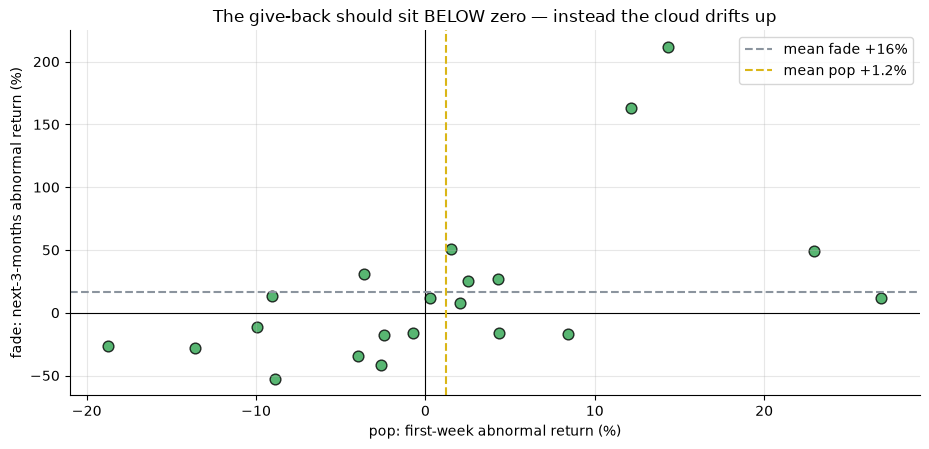

mean pop +1.2%   mean fade +16.2%  (a give-back would be negative)


In [2]:
if HAVE_REAL:
    pops = EV['pop'].values*100; fades = EV['fade'].values*100; labels = EV['ticker'].values
else:
    rng=np.random.default_rng(389)
    pops=rng.normal(R['pop'][0],8,R['n_priced']); fades=rng.normal(R['fade'][0],30,R['n_priced'])
    labels=[f'R{i}' for i in range(R['n_priced'])]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.scatter(pops, fades, c=GREEN, s=60, edgecolor='k', alpha=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.8)
ax.axhline(np.mean(fades), c=GREY, ls='--', label=f'mean fade {np.mean(fades):+.0f}%')
ax.axvline(np.mean(pops), c=AMBER, ls='--', label=f'mean pop {np.mean(pops):+.1f}%')
ax.set_xlabel('pop: first-week abnormal return (%)')
ax.set_ylabel('fade: next-3-months abnormal return (%)')
ax.set_title('The give-back should sit BELOW zero — instead the cloud drifts up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean pop {np.mean(pops):+.1f}%   mean fade {np.mean(fades):+.1f}%  (a give-back would be negative)')

There's the tell. If 'pop then give it back' were true, the dots would sit **below** the zero line (a negative fade). Instead the mean fade is **+16%** — the survivors drifted *up*, not down. The pop, meanwhile, hugs zero.

**The two legs as averages.** Mean abnormal pop and fade, with the win-rate (how often each leg is positive). A coin is 50%.

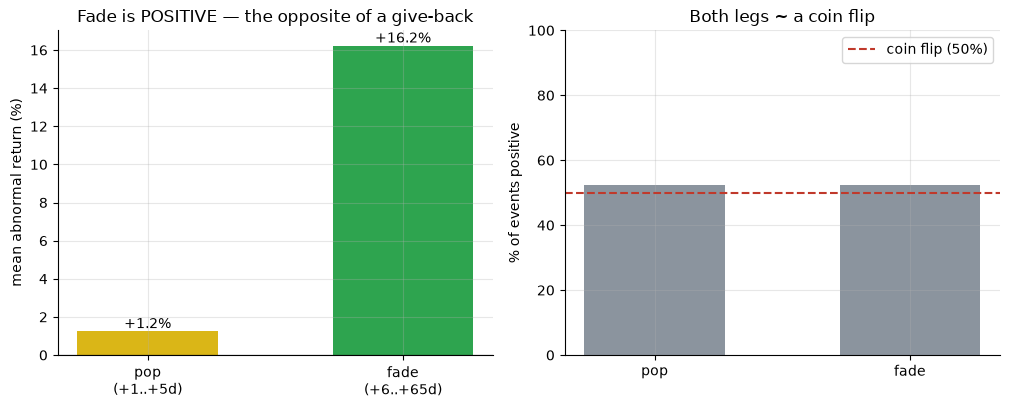

pop +1.2% (win 52%)   fade +16.2% (win 52%)


In [3]:
if HAVE_REAL:
    s = st.summarize(EV, B, placebo=False)
    pm, pw = s['pop']['mean']*100, s['pop']['win']*100
    fm, fw = s['fade']['mean']*100, s['fade']['win']*100
else:
    pm, pw, fm, fw = R['pop'][0], R['pop'][1], R['fade'][0], R['fade'][1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
a1.bar(['pop\n(+1..+5d)', 'fade\n(+6..+65d)'], [pm, fm], color=[AMBER, GREEN], width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean abnormal return (%)')
a1.set_title('Fade is POSITIVE — the opposite of a give-back')
for i,v in enumerate([pm,fm]): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a2.bar(['pop','fade'], [pw, fw], color=GREY, width=.55)
a2.axhline(50, c=RED, ls='--', label='coin flip (50%)')
a2.set_ylim(0,100); a2.set_ylabel('% of events positive'); a2.set_title('Both legs ~ a coin flip')
a2.legend(); plt.tight_layout(); plt.show()
print(f'pop {pm:+.1f}% (win {pw:.0f}%)   fade {fm:+.1f}% (win {fw:.0f}%)')

The pop is **+1.2%** and positive only **52%** of the time — a coin flip. The fade is **positive**, so there is no dump to short. Neither leg of the legend is there on the surviving names.

**Could a handful of random windows look this good?** The honest small-sample test: draw **21** *random* windows on the same stocks, over and over, and see where the real pop lands against pure luck.

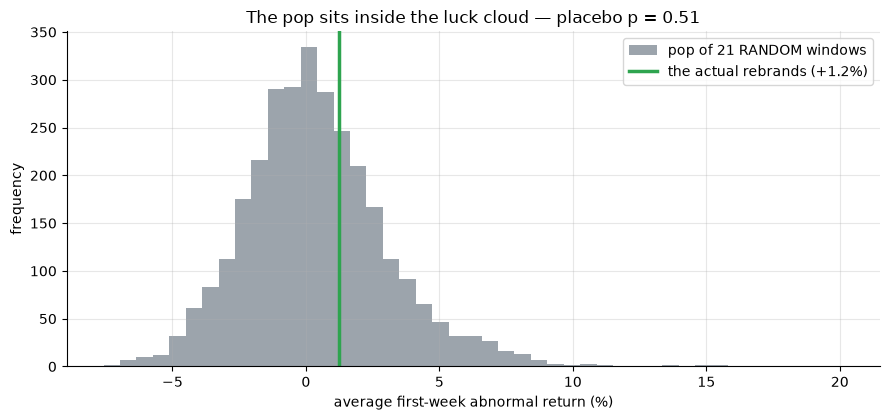

a random 21-window draw matches the pop 50% of the time — not rare


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(B, len(EV), leg='pop', observed=EV['pop'].mean(), n_draws=4000)
    obs = pl['obs']*100; pval = pl['p_value']
    # rebuild a small placebo cloud for the picture
    tickers=[c for c in B['prices'].columns if c!='SPY']
    exs=[st._excess_log_returns(B['prices'][t], B['prices']['SPY']) for t in tickers]
    exs=[s for s in exs if len(s)>80]; rng=np.random.default_rng(389)
    draws=[]
    for _ in range(3000):
        vals=[]
        for _ in range(len(EV)):
            s=exs[rng.integers(0,len(exs))]; p0=rng.integers(1,len(s)-7); vals.append(np.expm1(s.iloc[p0:p0+5].sum()))
        draws.append(np.mean(vals))
    draws=np.array(draws)*100
else:
    obs=R['pop'][0]; pval=R['pop'][3]; rng=np.random.default_rng(389); draws=rng.normal(0,2.0,3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label=f'pop of {R["n_priced"]} RANDOM windows')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the actual rebrands ({obs:+.1f}%)')
ax.set_xlabel('average first-week abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The pop sits inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random {R["n_priced"]}-window draw matches the pop {pval*100:.0f}% of the time — not rare')

The green line — the real rebrands' pop — sits **inside** the grey luck cloud (placebo *p* ≈ **0.50**). In plain terms: **a couple-dozen random press releases would look about this 'special' by chance.** The pop isn't magic; it's noise with a famous anecdote attached.

## 5 · The verdict

- **Signal — Weak.** The dot-com pop is real in the textbooks, but on ~21 *surviving* rebrands it's a faint **+1.2%** coin-flip — and the 'give-back' actually runs **+16% the wrong way**. Real as lore, weak as edge.
- **Tradability — Mirage.** Buy-the-pop / short-the-fade is **-15% per event before costs** — you bleed shorting a dump that never comes.
- **"Pop then dump"? — Busted.** We remember Long Blockchain and KodakCoin *because* they blew up — and they **delisted**, so they never enter a fair sample. The representative rebrand doesn't give it back.

## 6 · Could you actually trade it? — the give-back that isn't there

Forget significance and just price the believers' trade: **buy the pop, then short the fade.** Here's what that book makes per event, gross and net of the (large, small-cap) costs of four crossings.

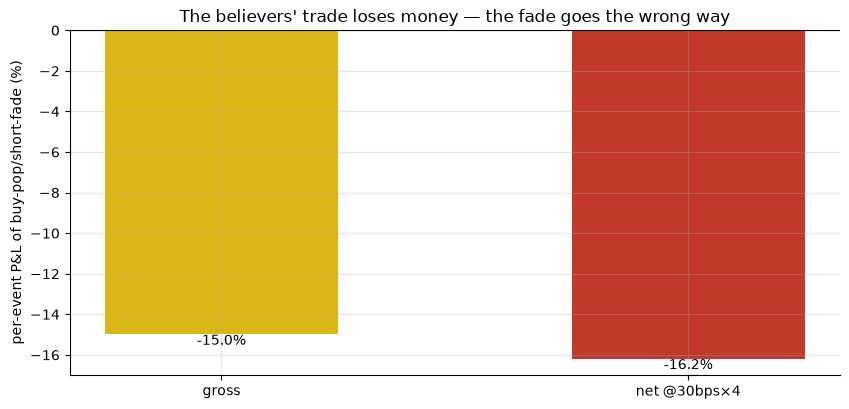

buy-pop/short-fade: -15.0% gross, -16.2% net — a money-loser before costs even bite


In [5]:
if HAVE_REAL:
    c = st.net_of_costs(EV, cost_bps=30.0)
    gc, nc = c['gross_combo']*100, c['net_combo']*100
else:
    gc, nc = R['cost']['gross_combo'], R['cost']['net_combo']
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(['gross', 'net @30bps×4'], [gc, nc], color=[AMBER, RED], width=.5)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('per-event P&L of buy-pop/short-fade (%)')
ax.set_title('The believers\' trade loses money — the fade goes the wrong way')
for i,v in enumerate([gc,nc]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='top')
plt.tight_layout(); plt.show()
print(f'buy-pop/short-fade: {gc:+.1f}% gross, {nc:+.1f}% net — a money-loser before costs even bite')

The combo is **-15% gross** and **-16% net**. The short leg is the killer: you're betting the stock gives the pop back, and on the survivors it *doesn't*. Costs only deepen a hole the missing give-back already dug. There's no machine here — just a story with two famous corpses.

## 7 · Going further 🚪

- **The other name effect.** [Study 169 — Fluent-Tickers](../169-fluent-tickers/) asks whether a *pronounceable* ticker carries a premium — same family (a label, not a fundamental), same verdict.
- **The anecdote trap.** [Study 343 — Data-Mining-Roulette](../343-data-mining-roulette/) shows how a few loud cases manufacture a 'law' that vanishes on a representative sample.
- **Add the corpses.** Our survivor tape is biased *for* the story; get delisted-stock data (Long Blockchain, KodakCoin, the dot-com renames) and the pop might be bigger — but so would the eventual −100%, which is a bankruptcy, not a tradable 'fade.'

*Think the rebrand pop is real and harvestable? Capture the events, draw the same number of random windows, and show the pop landing **outside** the cloud **and** a fade that's reliably negative — then we'll talk.*